In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , StratifiedKFold
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score , accuracy_score 
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from lightgbm import LGBMClassifier

In [18]:
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

cleveland = pd.read_csv('data/heart+disease/processed.cleveland.data', 
                         header=None, names=columns)
hungarian = pd.read_csv('data/heart+disease/processed.hungarian.data', 
                         header=None, names=columns)
switzerland = pd.read_csv('data/heart+disease/processed.switzerland.data', 
                           header=None, names=columns)
va = pd.read_csv('data/heart+disease/processed.va.data', 
                  header=None, names=columns)

#dataset = pd.concat([cleveland, hungarian, switzerland, va], ignore_index=True)
dataset = pd.read_csv("./data/heart.csv")

print(dataset.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [ ]:
dataset.replace('?', np.nan, inplace=True)

for col in dataset.columns:
    dataset[col] = dataset[col].astype(float)

X = dataset.drop('target', axis=1)
y = dataset['target'].apply(lambda x: 1 if x > 0 else 0).astype(int)

print(X.head())
print(y.head())

# print(X.isnull().sum())

X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42 , stratify=y)
X_train2 , X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.20, random_state=38 , stratify=y)
X_train3 , X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.20, random_state=60 , stratify=y)
#----------------------
X_train_with_target = X_train.copy()
X_train_with_target['target'] = y_train

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  3.0     145.0  233.0  1.0      0.0    150.0    0.0      2.3   
1  37.0  1.0  2.0     130.0  250.0  0.0      1.0    187.0    0.0      3.5   
2  41.0  0.0  1.0     130.0  204.0  0.0      0.0    172.0    0.0      1.4   
3  56.0  1.0  1.0     120.0  236.0  0.0      1.0    178.0    0.0      0.8   
4  57.0  0.0  0.0     120.0  354.0  0.0      1.0    163.0    1.0      0.6   

   slope   ca  thal  
0    0.0  0.0   1.0  
1    0.0  0.0   2.0  
2    2.0  0.0   2.0  
3    2.0  0.0   2.0  
4    2.0  0.0   2.0  
0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64


target
1    111
0     92
Name: count, dtype: int64
          count        mean        std    min    25%    50%    75%    max
age       203.0   54.418719   9.015775   29.0   48.0   56.0   60.5   74.0
sex       203.0    0.699507   0.459606    0.0    0.0    1.0    1.0    1.0
cp        203.0    0.960591   1.033318    0.0    0.0    1.0    2.0    3.0
trestbps  203.0  132.059113  17.585054  100.0  120.0  130.0  140.0  200.0
chol      203.0  245.635468  46.929219  126.0  212.0  243.0  274.0  417.0
fbs       203.0    0.177340   0.382900    0.0    0.0    0.0    0.0    1.0
restecg   203.0    0.487685   0.529894    0.0    0.0    0.0    1.0    2.0
thalach   203.0  149.600985  22.223959   88.0  132.0  152.0  164.5  202.0
exang     203.0    0.305419   0.461723    0.0    0.0    0.0    1.0    1.0
oldpeak   203.0    1.066995   1.147811    0.0    0.0    0.8    1.6    6.2
slope     203.0    1.428571   0.595837    0.0    1.0    1.0    2.0    2.0
ca        203.0    0.758621   0.997949    0.0    0.0    0.0  

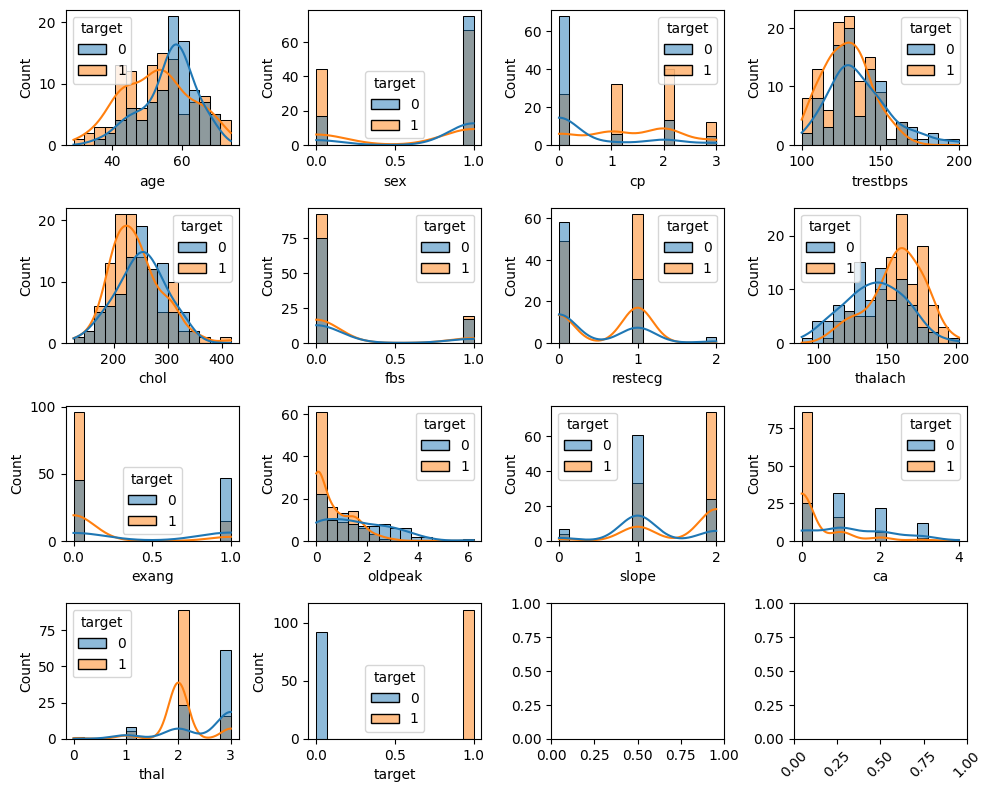

In [20]:
# EDA
# 1. target analysis
print(y_train.value_counts())
print(X_train.describe().T)
print(X_train.isnull().sum())
# sns.countplot(x=y )
# plt.show()
# 2. univariate analysis (only feature)
fig , axes = plt.subplots(nrows= 4 , ncols= 4 , figsize = (10,8))
axes = axes.flatten()

for idx,col in enumerate(X_train_with_target.columns):
    ax = axes[idx]
    sns.histplot(data = X_train_with_target, x = col , hue ="target" , kde=True , ax = ax , bins=15 )

fig.tight_layout(pad=1.0)
plt.xticks(rotation=45)
plt.show()


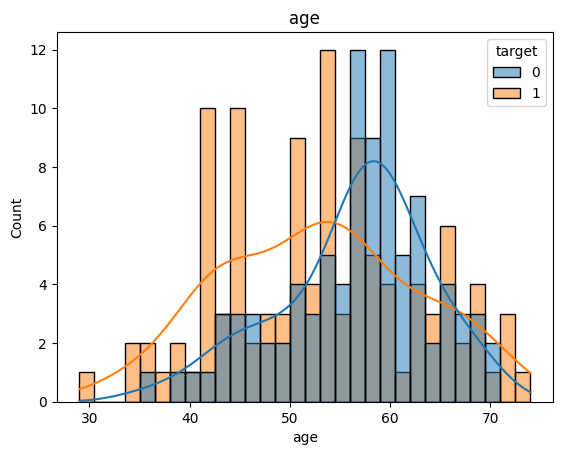

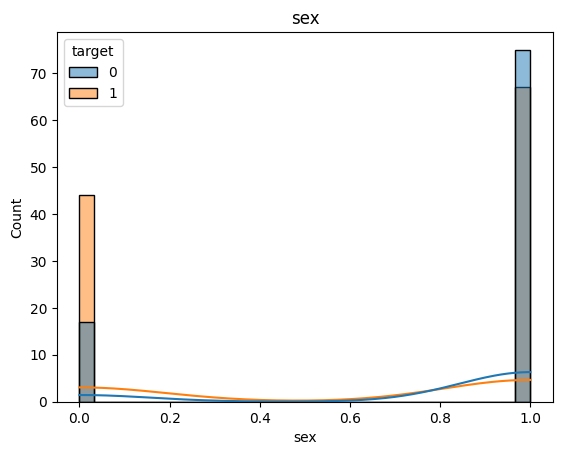

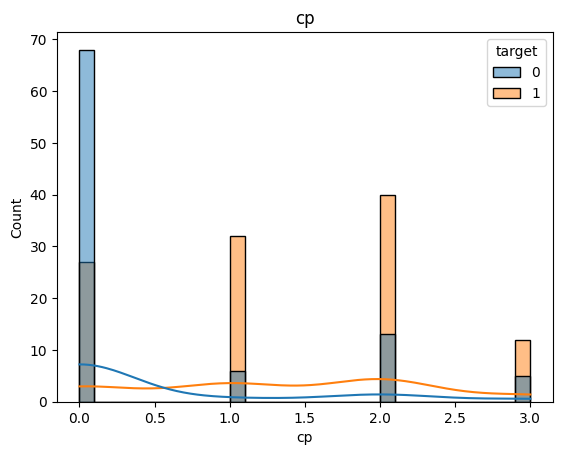

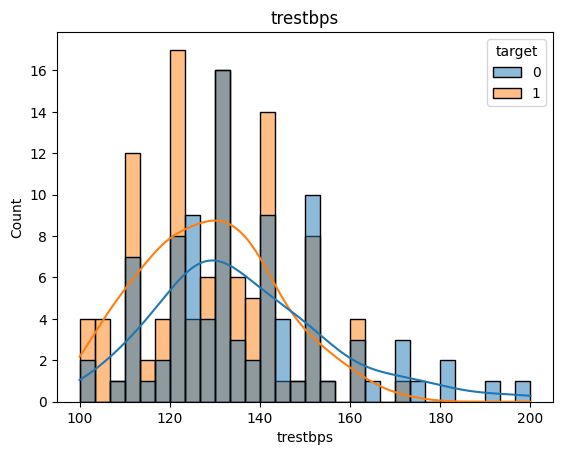

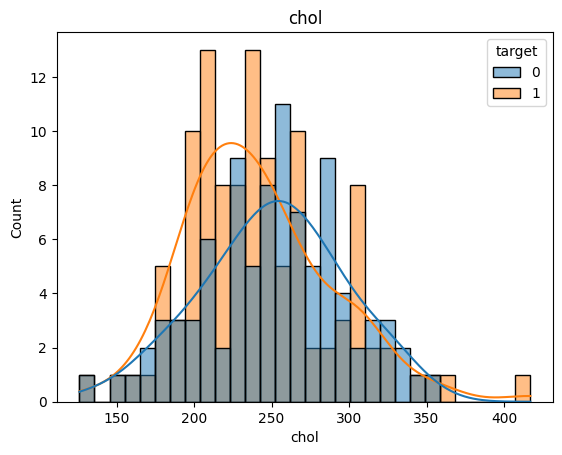

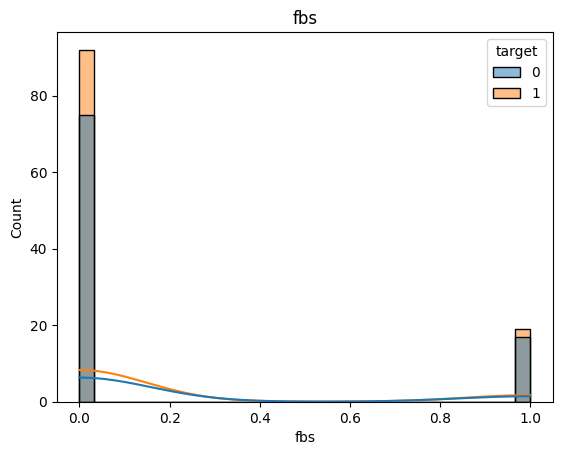

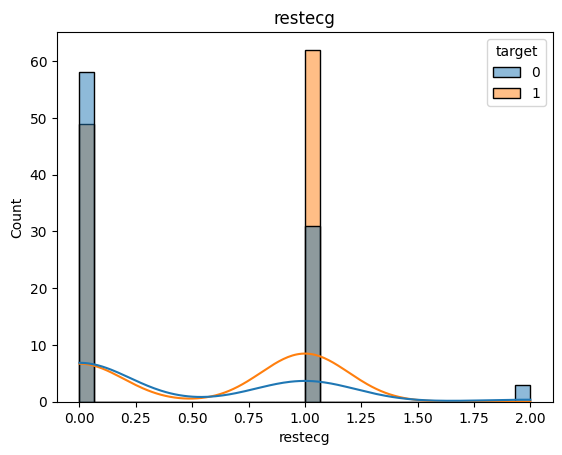

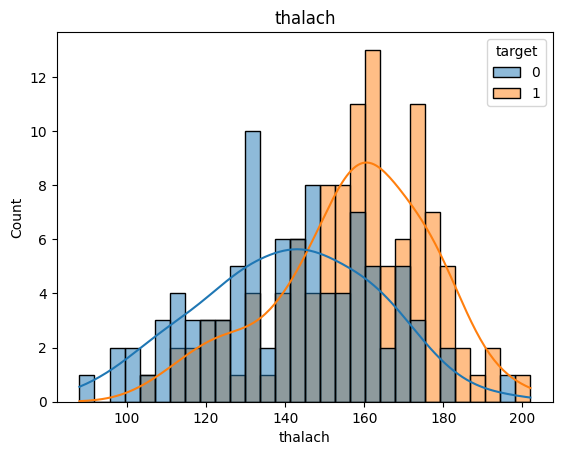

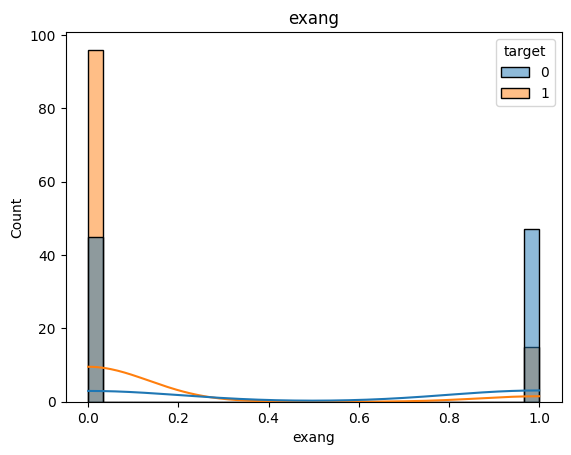

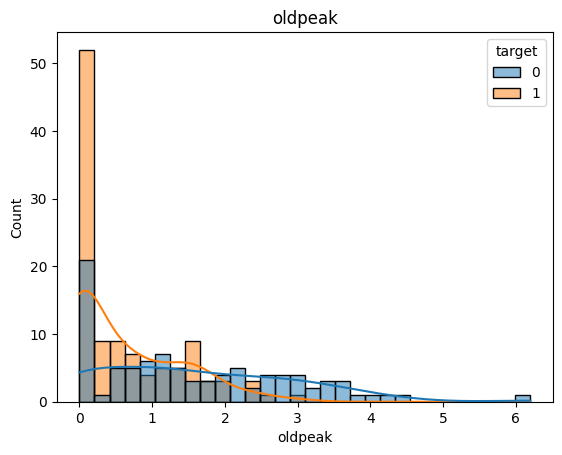

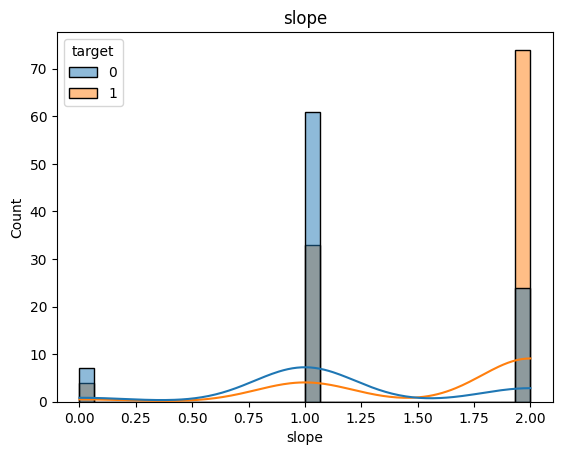

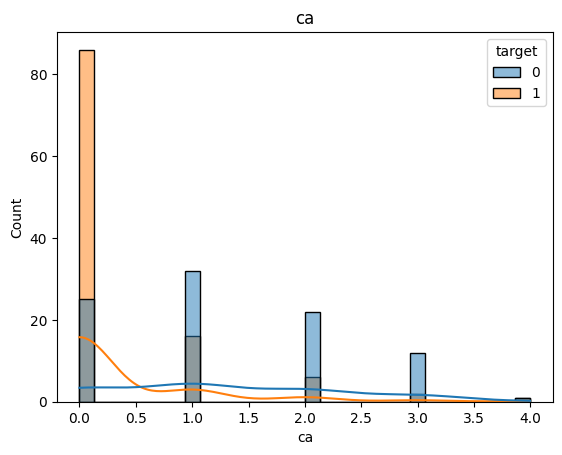

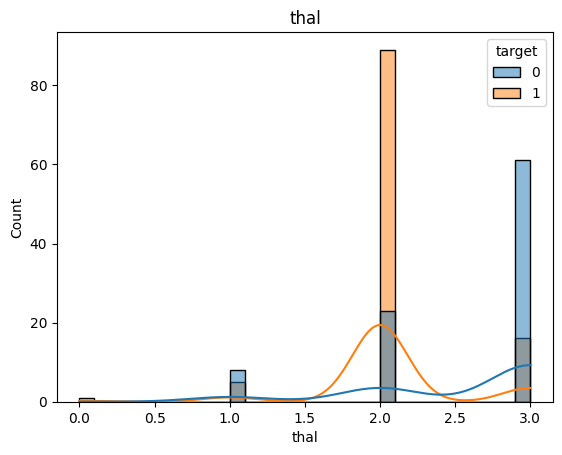

In [21]:
for col in X_train_with_target.columns:
    if col != "target":
        plt.figure()
        sns.histplot(data=X_train_with_target, x=col, hue="target", bins=30, kde=True)
        plt.title(col)
        plt.show()

In [22]:
# 3. bivariate analysis (feature-feature)
# 4. feature - target

In [23]:
numeric_features = ["age","trestbps","chol","thalach","oldpeak"]
ordinal_features = ["cp","restecg","ca"]
nominal_features = ["sex","fbs","exang","slope","thal"]
cat_features = ordinal_features + nominal_features

          age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
age       NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
sex       NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
cp        NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
trestbps  NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
chol      NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
fbs       NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
restecg   NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
thalach   NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
exang     NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
oldpeak   NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
slope     NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
ca        NaN  NaN NaN      

<Axes: >

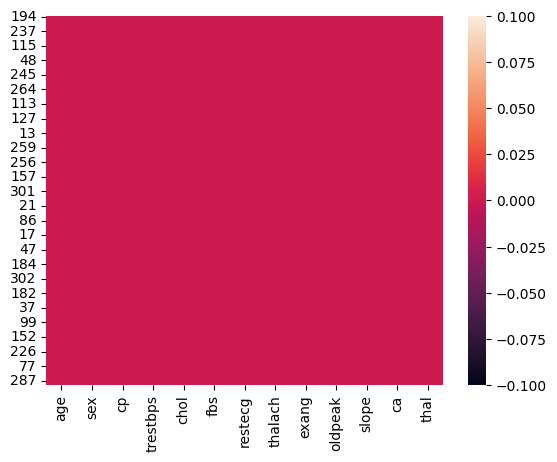

In [24]:
# missing values analysis
# check if any pattern in missing data
 
X_train_missing = X_train.isnull()
print(X_train_missing.corr())
sns.heatmap(X_train_missing)

In [25]:
# add sentinel for together missing data
# together_missing = ["thalach","exang","oldpeak","trestbps"]
# X_train["thalach_exang_oldpeak_trestbps_missing"] = X_train["thalach"].isnull() & X_train["exang"].isnull() & \
#     X_train["oldpeak"].isnull() & X_train["trestbps"].isnull()

# X_test["thalach_exang_oldpeak_trestbps_missing"] = X_test["thalach"].isnull() & X_test["exang"].isnull() & \
#     X_test["oldpeak"].isnull() & X_test["trestbps"].isnull()

In [26]:
# handling missing values
# for col in numeric_features:
#     median = X_train[col].median()
#     X_train[f"{col}_missing_flag"] = X_train[col].isnull().astype(int)
#     X_train[col] = X_train[col].fillna(median)

#     X_test[f"{col}_missing_flag"] = X_test[col].isnull().astype(int)
#     X_test[col] = X_test[col].fillna(median)

# for col in cat_features:
#     mode = X_train[col].mode()[0]
#     X_train[f"{col}_missing_flag"] = X_train[col].isnull().astype(int)
#     X_train[col] = X_train[col].fillna(mode)

#     X_test[f"{col}_missing_flag"] = X_test[col].isnull().astype(int)
#     X_test[col] = X_test[col].fillna(mode)
    
# print(X_train.isnull().sum())

# X_train.loc[X_train["thalach_exang_oldpeak_trestbps_missing"],"thalach"] = -999.0 # sentinel
# X_test.loc[X_test["thalach_exang_oldpeak_trestbps_missing"],"thalach"] = -999.0 # sentinel

# X_train.loc[X_train["thalach_exang_oldpeak_trestbps_missing"],"exang"] = -999.0 # sentinel
# X_test.loc[X_test["thalach_exang_oldpeak_trestbps_missing"],"exang"] = -999.0 # sentinel

# X_train.loc[X_train["thalach_exang_oldpeak_trestbps_missing"],"oldpeak"] = -999.0 # sentinel
# X_test.loc[X_test["thalach_exang_oldpeak_trestbps_missing"],"oldpeak"] = -999.0 # sentinel

# X_train.loc[X_train["thalach_exang_oldpeak_trestbps_missing"],"trestbps"] = -999.0 # sentinel
# X_test.loc[X_test["thalach_exang_oldpeak_trestbps_missing"],"trestbps"] = -999.0 # sentinel


In [27]:
# Feature Engineering

#nominal_features = ["sex","fbs","exang","slope","thal"]

X_train["thal"] = X_train["thal"].astype(int).astype("category")
X_test["thal"] = X_test["thal"].astype(int).astype("category")

X_train["sex"] = X_train["sex"].astype(int).astype("category")
X_test["sex"] = X_test["sex"].astype(int).astype("category")

X_train["restecg"] = X_train["restecg"].astype(int).astype("category")
X_test["restecg"] = X_test["restecg"].astype(int).astype("category")

X_train["slope"] = X_train["slope"].astype(int).astype("category")
X_test["slope"] = X_test["slope"].astype(int).astype("category")




# target encoding

# for col in nominal_features:
#     te_map = X_train_with_target.groupby(col)["target"].mean()
#     X_train[f"{col}_te"] = X_train[col].map(te_map)
#     X_test[f"{col}_te"] = X_train[col].map(te_map)



# # WoE

# df = X_train_with_target.copy()

# for col in nominal_features:
#     grouped = df.groupby(col)["target"].agg(["count", "sum"])
#     grouped.columns = ["total", "bad"]
#     grouped["good"] = grouped["total"] - grouped["bad"]

#     total_good = grouped["good"].sum()
#     total_bad = grouped["bad"].sum()

#     eps = 1e-6
#     grouped["woe"] = np.log(
#         ((grouped["good"] / total_good) + eps) /
#         ((grouped["bad"] / total_bad) + eps)
#     )

#     woe_map = grouped["woe"].to_dict()


#     X_train[f"{col}_WoE"] = X_train[col].map(woe_map)
#     X_test[f"{col}_WoE"] = X_test[col].map(woe_map)

# stats encoding with smoothing

alpha = 10  # smoothing strength
global_mean = X_train_with_target["target"].mean()

for col in nominal_features:
    stats = X_train_with_target.groupby(col)["target"].agg(["mean","std","count"])

    # smoothing
    stats["mean_smooth"] = (
        stats["count"] * stats["mean"] + alpha * global_mean
    ) / (stats["count"] + alpha)

    # frequency
    stats["frequency"] = stats["count"] / stats["count"].sum()

    for s in ["mean_smooth", "std", "count", "frequency"]:
        X_train[f"{col}_{s}"] = X_train[col].map(stats[s]).astype("float32")
        X_test[f"{col}_{s}"] = X_test[col].map(stats[s]).astype("float32")


#numeric_features = ["age","trestbps","chol","thalach","oldpeak"]

# X_train["age_chol"] = X_train["age"] * X_train["chol"] 
# X_test["age_chol"] = X_test["age"] * X_test["chol"] 



In [28]:
from xgboost import XGBClassifier


# model = LGBMClassifier(
#     n_estimators=15000,
#     learning_rate=0.01,
#     max_depth=5,
#     min_child_weight=5,
#     subsample=0.80,
#     colsample_bytree=0.80,
#     objective = "binary",
#     eval_metric="auc",
#     random_state=42,
#     verbose=-1,
#     n_jobs=-1
# )

model = XGBClassifier(
    n_estimators=15000,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    objective = "binary:logistic",
    enable_categorical= True,
    eval_metric="auc",
    random_state=42,
    verbosity=0, 
    n_jobs=-1
)

In [29]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_train))
oof_probas = np.zeros(len(X_train))

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(X_tr, y_tr)
    oof_preds[val_idx] = model.predict(X_val)
    oof_probas[val_idx] = model.predict_proba(X_val)[:,1]



print("OOF Metrics on train (CV):")
print({
    "accuracy": accuracy_score(y_train, oof_preds),
    #"precision": precision_score(y_train, oof_preds),
    #"recall": recall_score(y_train, oof_preds),
    #"f1": f1_score(y_train, oof_preds),
    "roc_auc": roc_auc_score(y_train, oof_probas),
    #"pr_auc": average_precision_score(y_train, oof_probas)
})

model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:,1]

print("Holdout Metrics on test:")
print({
    "accuracy": accuracy_score(y_test, y_test_pred),
    #"precision": precision_score(y_test, y_test_pred),
    #"recall": recall_score(y_test, y_test_pred),
    #"f1": f1_score(y_test, y_test_pred),
    "roc_auc": roc_auc_score(y_test, y_test_proba),
    #"pr_auc": average_precision_score(y_test, y_test_proba)
})

OOF Metrics on train (CV):
{'accuracy': 0.812807881773399, 'roc_auc': 0.8753427340383862}
Holdout Metrics on test:
{'accuracy': 0.77, 'roc_auc': 0.8623188405797102}


BASELINE
OOF Metrics on train (CV):
{'accuracy': 0.7676630434782609, 'precision': 0.780952380952381, 'recall': 0.8058968058968059, 'f1': 0.7932285368802902, 'roc_auc': 0.8300038087272129, 'pr_auc': 0.8039681699134036}
Holdout Metrics on test:
{'accuracy': 0.8043478260869565, 'precision': 0.8055555555555556, 'recall': 0.8529411764705882, 'f1': 0.8285714285714286, 'roc_auc': 0.8803204208512673, 'pr_auc': 0.8813899091801921}

In [30]:
feature_importances_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)
feature_importances_df

,feature,importance
21,exang_mean_smooth,0.123568
30,thal_std,0.120713
8,exang,0.107928
29,thal_mean_smooth,0.103645
11,ca,0.064347
13,sex_mean_smooth,0.057658
2,cp,0.051858
12,thal,0.049892
26,slope_std,0.037102
1,sex,0.032381


In [31]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train,
    y_train,
    cv=3,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs = -1
)

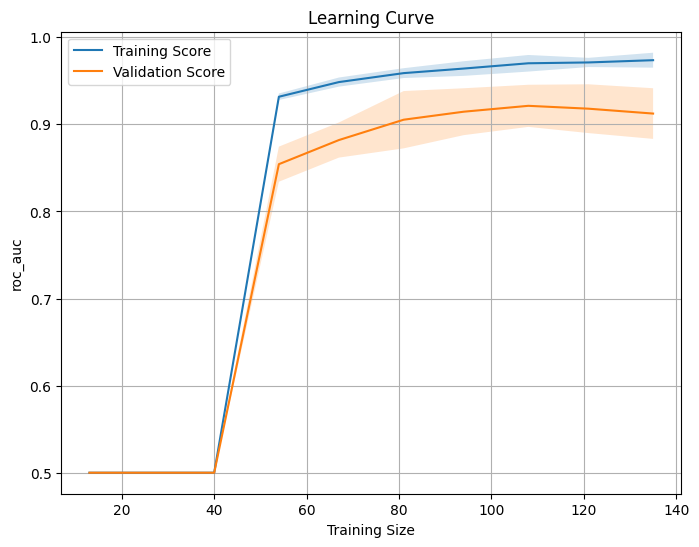

In [32]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Grafik
plt.figure(figsize=(8, 6))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)

plt.plot(train_sizes, val_mean, label="Validation Score")
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)

plt.xlabel("Training Size")
plt.ylabel("roc_auc")
plt.title("Learning Curve")
plt.legend()
plt.grid()

plt.show()